<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT1610: Cálculo I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 03: Continuidad</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> XXX | <b>Fecha:</b> XX de XXX, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>
</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contexto y Referencias</h3>
    <p>Este laboratorio profundiza en la noción de <b>continuidad</b>, conectando los límites con el comportamiento local de las funciones, según el <b>Capítulo 2.5 de Stewart</b>. Analizaremos cuándo una "pequeña" variación en el dominio produce una "pequeña" variación en la imagen y cómo identificar diferentes tipos de rupturas.</p>
</div>

<div style="display: flex; gap: 20px;">
    <div style="flex: 1; border: 1px solid #27ae60; border-left: 8px solid #27ae60; padding: 15px; border-radius: 5px;">
        <h3 style="color: #27ae60; margin-top: 0;">Contenidos</h3>
        <ol>
            <li>Definición formal de continuidad en un punto.</li>
            <li>Clasificación de discontinuidades (Evitables, de Salto e Infinitas).</li>
            <li>Continuidad en intervalos y funciones compuestas.</li>
            <li>Teorema del Valor Intermedio (TVI).</li>
        </ol>
    </div>
    <div style="flex: 1; border: 1px solid #f39c12; border-left: 8px solid #f39c12; padding: 15px; border-radius: 5px;">
        <h3 style="color: #f39c12; margin-top: 0;">Objetivos de Aprendizaje</h3>
        <ul>
            <li>Implementar funciones definidas por tramos en Python.</li>
            <li>Visualizar e identificar gráficamente tipos de discontinuidad.</li>
            <li>Resolver problemas de parámetros para asegurar continuidad usando SymPy.</li>
            <li>Aplicar el TVI para localizar raíces de funciones continuas.</li>
        </ul>
    </div>
</div>

In [1]:
# importar librerias de la sesion
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from ipywidgets import interact, widgets

# Configuración para visualización matemática
sp.init_printing()
%matplotlib inline

# Configuración de estilo
try: plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError: plt.style.use('seaborn-whitegrid') # Nombre antiguo
plt.rcParams['figure.figsize'] = (7, 4)

### 1. Definición de Continuidad
Según Stewart, una función $f$ es **continua en un número $a$** si se cumplen tres condiciones:
1. La función está definida: $f(a)$ existe ($a$ está en el dominio de $f$).
2. El límite existe: $\displaystyle \lim_{x \to a} f(x)$ existe (es decir, los límites laterales existen y son iguales).
3. El límite es igual a la función definida en el punto: $\displaystyle \lim_{x \to a} f(x) = f(a)$.

Si $f$ no es continua en $a$, decimos que $f$ tiene una **discontinuidad** en dicho punto.

Intuitivamente, una función es continua si podemos dibujar su gráfica sin levantar el lápiz del papel. Matemáticamente, esto significa que pequeños cambios en $x$ producen pequeños cambios en $f(x)$.

### Ejemplo 1.1: Verificación Analítica con Python
Comprobemos analíticamente la continuidad de la función polinomial $f(x) = x^2 - 3x + 4$ en $x = 2$ utilizando Cálculo Simbólico (`SymPy`).

In [2]:
# Ejemplo 1.1: Verificación usando SymPy
x = sp.Symbol('x')
f = x**2 - 3*x + 4
a = 2

# Evaluamos y calculamos límite
f_a = f.subs(x, a)
lim_f = sp.limit(f, x, a)

print(f"Criterio 1: f({a}) = {f_a}")
print(f"Criterio 2: Limite = {lim_f}")
print(f"Criterio 3: ¿Límite == f(a)? -> {f_a == lim_f}")

Criterio 1: f(2) = 2
Criterio 2: Limite = 2
Criterio 3: ¿Límite == f(a)? -> True


### Ejemplo 1.2: Aplicación a la Ingeniería (Perfil Térmico)
Imagina dos barras de metales soldadas en $x=0$. La temperatura se modela por la siguiente función:

$$
T(x) = 
\begin{cases} 
50 \cos(x) & \text{si } x \leq 0 \\
A e^{-0.5x} & \text{si } x > 0 
\end{cases}
$$

Para que la distribución térmica sea físicamente válida, calculemos el valor de la constante $A$ que garantiza la continuidad en $x=0$.

In [3]:
# Ejemplo 1.2: Encontrar constante A
x, A = sp.symbols('x A')
T_izq = 50 * sp.cos(x)
T_der = A * sp.exp(-0.5*x)

# Calculamos límites laterales en x = 0
L_izq = sp.limit(T_izq, x, 0, dir='-')
L_der = sp.limit(T_der, x, 0, dir='+')

# Resolvemos la ecuación L_izq == L_der
ecuacion = sp.Eq(L_izq, L_der)
sol_A = sp.solve(ecuacion, A)[0]
print(f"El valor de A para que no haya salto térmico es: {sol_A}")

El valor de A para que no haya salto térmico es: 50


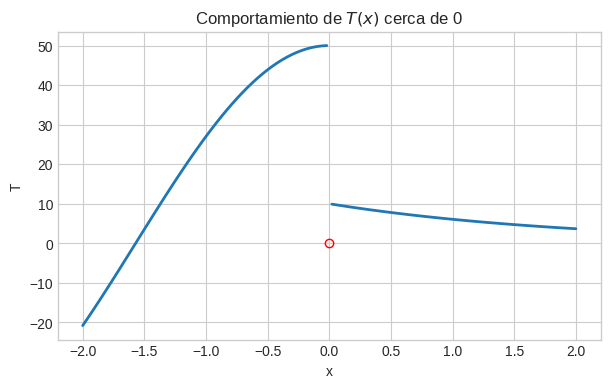

In [8]:
x = np.linspace(-2,2,100)
A = 10.0
T_izq = 50 * np.cos(x[x<0])
T_der = A * np.exp(-0.5*x[x>0])
plt.plot(x[x<0], T_izq, lw=2, color='C00')
plt.plot(x[x>0], T_der, lw=2, color='C00')
plt.plot(0,0,'o',fillstyle='none',color='r')
plt.title('Comportamiento de $T(x)$ cerca de 0')
plt.xlabel('x');plt.ylabel('T'); plt.show()

# **2. Clasificación de Discontinuidades**

Cuando los criterios de continuidad fallan, la discontinuidad se clasifica en uno de tres tipos:

1. **Evitable (Removable):** El límite $\lim_{x \to a} f(x)$ existe, pero $f(a)$ es distinto o indefinido. (Un "agujero").
2. **De Salto (Jump):** Los límites laterales existen y son finitos, pero son diferentes. (Un "escalón").
3. **Infinita:** Al menos uno de los límites laterales tiende a $+\infty$ o $-\infty$. (Una "asíntota vertical").

### Ejemplo 2.1: Discontinuidad Evitable
Analicemos la función de señales $f(x) = \frac{\sin(x)}{x}$ en $x=0$.

In [9]:
# Ejemplo 2.1: Discontinuidad evitable
x = sp.Symbol('x')
f = sp.sin(x)/x

limite = sp.limit(f, x, 0)
print(f"La función f(0) arroja división por cero, pero su límite es: {limite}")
print("Es una discontinuidad evitable.")


La función f(0) arroja división por cero, pero su límite es: 1
Es una discontinuidad evitable.


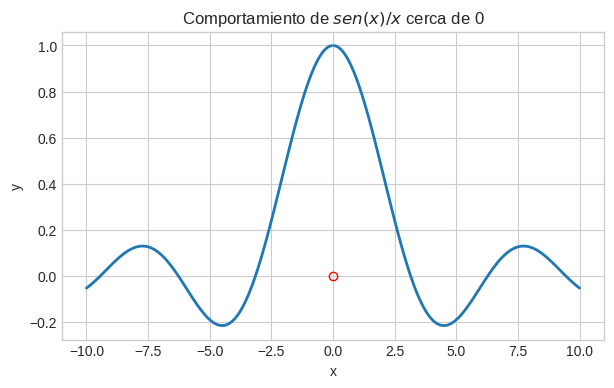

In [11]:
x = np.linspace(-10,10,200)
x_izq=x[x<0]
x_der=x[x>0]
y_izq = np.sin(x_izq)/x_izq
y_der = np.sin(x_der)/x_der
plt.plot(x_izq, y_izq, lw=2, color='C00')
plt.plot(x_der, y_der, lw=2, color='C00')
plt.plot(0,0,'o',fillstyle='none',color='r')
plt.title('Comportamiento de $sen(x)/x$ cerca de 0')
plt.xlabel('x');plt.ylabel('y'); plt.show()

### Ejemplo 2.2: Discontinuidad de Salto (Circuito)
La función de Heaviside (Escalón Unitario) enciende sistemas abruptamente:
$$H(t) = \begin{cases} 0 & t < 0 \\ 1 & t \geq 0 \end{cases}$$

In [12]:
# Ejemplo 2.2: Discontinuidad de salto
t = sp.Symbol('t')
H = sp.Heaviside(t)

lim_izq = sp.limit(H, t, 0, dir='-')
lim_der = sp.limit(H, t, 0, dir='+')
print(f"Límite Izquierdo: {lim_izq} | Límite Derecho: {lim_der}")
print("Límites finitos pero distintos -> Discontinuidad de Salto.")


Límite Izquierdo: 0 | Límite Derecho: 1
Límites finitos pero distintos -> Discontinuidad de Salto.


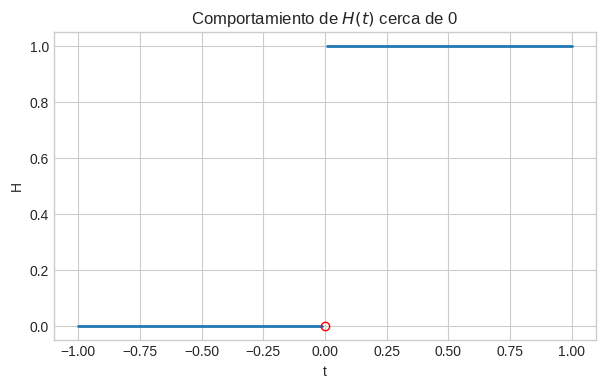

In [14]:
x = np.linspace(-1,1,100)
x_izq=x[x<0]
x_der=x[x>0]
y_izq = np.zeros(x_izq.size)
y_der = np.ones(x_der.size)
plt.plot(x_izq, y_izq, lw=2, color='C00')
plt.plot(x_der, y_der, lw=2, color='C00')
plt.plot(0,0,'o',fillstyle='none',color='r')
plt.title('Comportamiento de $H(t)$ cerca de 0')
plt.xlabel('t');plt.ylabel('H'); plt.show()

# **3. Continuidad en Intervalos y Funciones Compuestas**

- Una función es continua en un **intervalo abierto** $(a, b)$ si es continua en cada punto del intervalo.
- Para un **intervalo cerrado** $[a, b]$, también se exige continuidad lateral en los extremos: $\lim_{x \to a^+} f(x) = f(a)$ y $\lim_{x \to b^-} f(x) = f(b)$.

**Funciones Compuestas:** Si una señal es $g(x)$ y pasa por un sensor $f(x)$, la lectura es $(f \circ g)(x) = f(g(x))$. Si $g$ es continua en $a$ y $f$ es continua en $g(a)$, ¡la composición completa es continua!

### Ejemplo 3.1: Continuidad en el extremo de un intervalo
Consideremos la semiesfera de tensión geométrica $y = \sqrt{9 - x^2}$ en el intervalo $[-3, 3]$. Evaluemos la continuidad en el extremo derecho $x = 3$.

In [15]:
# Ejemplo 3.1: Límite lateral en extremo cerrado
x = sp.Symbol('x')
y = sp.sqrt(9 - x**2)

# Límite por la izquierda (acercándonos desde dentro del intervalo)
lim_izq = sp.limit(y, x, 3, dir='-')
evaluacion = y.subs(x, 3)

print(f"Límite lateral al aproximarse a x=3: {lim_izq}")
print(f"Evaluación y(3): {evaluacion}")
print("Al coincidir, la función es continua por la izquierda en x=3.")


Límite lateral al aproximarse a x=3: 0
Evaluación y(3): 0
Al coincidir, la función es continua por la izquierda en x=3.


### Ejemplo 3.2: Función Compuesta
Evaluemos analíticamente el dominio de continuidad para $h(x) = e^{\sin(x)}$. Dado que $\sin(x)$ es continua en todo $\mathbb{R}$ y $e^x$ es continua en $\mathbb{R}$, $h(x)$ debería serlo.

In [16]:
# Ejemplo 3.2: Comprobación simple
x = sp.Symbol('x')
h = sp.exp(sp.sin(x))

# Evaluamos un punto arbitrario como x = pi
limite_pi = sp.limit(h, x, sp.pi)
eval_pi = h.subs(x, sp.pi)

print(f"Límite en pi: {limite_pi} | h(pi): {eval_pi}")


Límite en pi: 1 | h(pi): 1


# **4. Teorema del Valor Intermedio (TVI)**

El **Teorema del Valor Intermedio** garantiza que si una función $f$ es continua en un intervalo cerrado $[a, b]$, toma todos los valores intermedios entre $f(a)$ y $f(b)$.

Si un auto acelera de $0$ a $100 \text{ km/h}$, el TVI garantiza que en algún instante su velocidad fue de exactamente $65 \text{ km/h}$. En matemáticas, se usa ampliamente para garantizar que una ecuación tiene una raíz (cuando pasa de valores negativos a positivos, cruza obligatoriamente por el 0).

### Ejemplo 4.1: Analítica de Raíces
Demostremos que el polinomio de diseño $f(x) = x^3 - 3x + 1$ tiene una raíz real entre $[0, 1]$.

In [17]:
# Ejemplo 4.1: Aplicando el TVI
x = sp.Symbol('x')
f = x**3 - 3*x + 1

f_0 = f.subs(x, 0)
f_1 = f.subs(x, 1)

print(f"En x=0, f(0) = {f_0}")
print(f"En x=1, f(1) = {f_1}")
print("Al ser f(x) un polinomio continuo y cambiar de signo (+ a -), el TVI garantiza una raíz (f(c)=0) en (0, 1).")


En x=0, f(0) = 1
En x=1, f(1) = -1
Al ser f(x) un polinomio continuo y cambiar de signo (+ a -), el TVI garantiza una raíz (f(c)=0) en (0, 1).


### Ejemplo 4.2: Visualizando el TVI
Tracemos la gráfica para confirmar visualmente el cruce del eje $x$ predicho por el teorema.

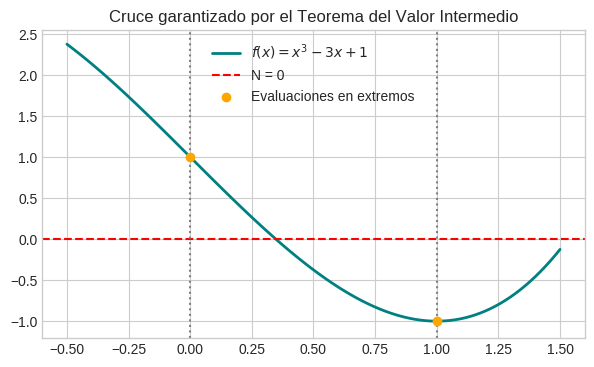

In [18]:
# Ejemplo 4.2: Visualización
x_vals = np.linspace(-0.5, 1.5, 100)
f_vals = x_vals**3 - 3*x_vals + 1

plt.plot(x_vals, f_vals, label='$f(x) = x^3 - 3x + 1$', color='teal', lw=2)
plt.axhline(0, color='red', linestyle='--', label='N = 0')
plt.axvline(0, color='gray', linestyle=':')
plt.axvline(1, color='gray', linestyle=':')
plt.scatter([0, 1], [1, -1], color='orange', zorder=5, label='Evaluaciones en extremos')

plt.title('Cruce garantizado por el Teorema del Valor Intermedio')
plt.legend()
plt.show()


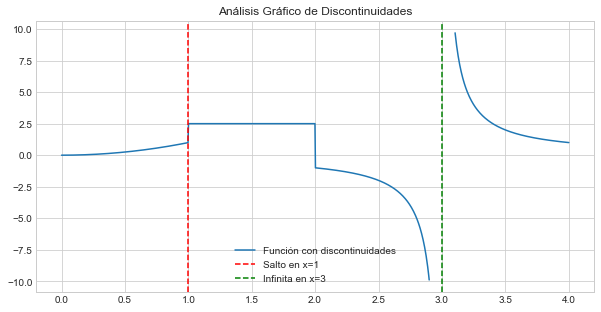

In [3]:
# Definimos una función por tramos para observar diferentes discontinuidades
def f_tramos(val_x):
    if val_x < 1:
        return val_x**2
    elif 1 <= val_x < 2:
        return 2.5  # Salto
    else:
        return 1 / (val_x - 3) # Asíntota en x=3

# Visualización
x_vals = np.linspace(0, 4, 1000)
y_vals = [f_tramos(val) for val in x_vals]
# Limpiar valores muy grandes cerca de la asíntota para mejor visualización
y_vals = [y if abs(y) < 10 else np.nan for y in y_vals]

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label="Función con discontinuidades")
plt.axvline(x=1, color='r', linestyle='--', label='Salto en x=1')
plt.axvline(x=3, color='g', linestyle='--', label='Infinita en x=3')
plt.title("Análisis Gráfico de Discontinuidades")
plt.legend()
plt.grid(True)
plt.show()

### Ejercicio Propuesto: El problema del puente
Considere la función definida por tramos:
$$f(x) = \begin{cases} cx^2 + 2x & \text{si } x < 2 \\ x^3 - cx & \text{si } x \ge 2 \end{cases}$$
Utilice **SymPy** para encontrar el valor de la constante $c$ que hace que la función sea continua en todo su dominio.

### JNB LAB: Localización de Raíces (TVI)
El **Teorema del Valor Intermedio** establece que si $f$ es continua en $[a, b]$ y $N$ es un número entre $f(a)$ y $f(b)$, existe al menos un $c \in (a, b)$ tal que $f(c) = N$.

**Misión:** Demuestre gráficamente que la función $f(x) = \cos(x) - x$ tiene una raíz en el intervalo $[0, 1]$. Utilice el método de bisección simple para encontrar una aproximación.

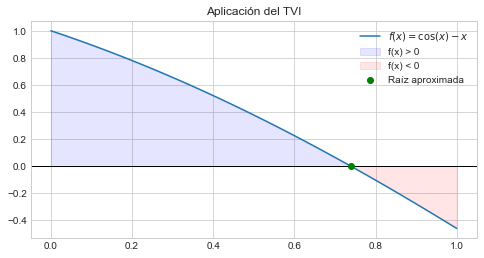

In [4]:
# Visualización del TVI
x_p = np.linspace(0, 1, 100)
y_p = np.cos(x_p) - x_p

plt.figure(figsize=(8, 4))
plt.plot(x_p, y_p, label='$f(x) = \cos(x) - x$')
plt.axhline(0, color='black', lw=1)
plt.fill_between(x_p, y_p, where=(y_p >= 0), color='blue', alpha=0.1, label='f(x) > 0')
plt.fill_between(x_p, y_p, where=(y_p <= 0), color='red', alpha=0.1, label='f(x) < 0')
plt.scatter([0.739], [0], color='green', zorder=5, label='Raíz aproximada')
plt.legend()
plt.grid(True)
plt.title("Aplicación del TVI")
plt.show()

<div class="alert alert-block alert-success" style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;"> 
    <h2 style="color: #2e7d32; margin-top: 0;">🏁 Ticket de Salida</h2>
    <p style="font-size: 1.1em; color: #1b5e20;"><strong>¡Felicidades!</strong> Hemos llegado al final de los contenidos teóricos. Pon a prueba tu aprendizaje de las cuatro secciones resolviendo estos retos de modelación.</p>
    <h3 style="color: #2e7d32; margin-top: 15px;">💻 Ejercicios: </h3>
</div>

### Ejercicio 1: Continuidad Paramétrica (Tema 1)
Una viga sujeta a cargas tiene un momento flector modelado por:
$$M(x) = \begin{cases} c x^2 + 2x & \text{si } x \leq 2 \\ x^3 - cx & \text{si } x > 2 \end{cases}$$
1. Encuentre el valor de la constante $c$ tal que el momento $M(x)$ sea **continuo** en toda la viga ($x=2$).
2. Compruebe su resultado imprimiendo los límites laterales de $M(x)$.

---

In [ ]:
# Escriba su código aquí

### Ejercicio 2: Diagnóstico de Discontinuidades (Tema 2)
El modelo de ganancia de un sistema es: $G(s) = \frac{s^2 - 4}{s^2 - s - 2}$
1. Encuentre los puntos $s$ donde el denominador es cero (use `sp.solve()`).
2. Calcule los límites laterales en cada uno de esos puntos para **clasificar** la discontinuidad (Evitable, de Salto o Infinita).

---

In [ ]:
# Escriba su código aquí

### Ejercicio 3: Composiciones y Dominio Seguro (Tema 3)
La presión del aceite de una bomba es $P(t) = t^2 - 4$ y el sensor de lectura requiere que el logaritmo reciba valores estrictamente positivos: $S(P) = \ln(P)$.
1. Defina matemáticamente en código la función compuesta $S(P(t))$.
2. Grafique la función compuesta $S(t)$ pero solo en el intervalo $[3, 6]$ para verificar visualmente que opera de manera continua sin errores matemáticos.

---

In [ ]:
# Escriba su código aquí

### Ejercicio 4: Evitación de Colisiones usando el TVI (Tema 4)
Dos drones vuelan en líneas verticales. La altura del Drone 1 es $h_1(t) = t^2 + 1$ y la del Drone 2 es $h_2(t) = \cos(\pi t) + 3$ (en metros y $t$ en segundos).
1. Defina una función de "diferencia de alturas" $D(t) = h_1(t) - h_2(t)$.
2. Evaluando $D(1)$ y $D(2)$, use código para demostrar bajo el TVI si existe la certeza de que ambos drones cruzaron la misma altitud (potencial colisión) entre $t=1$ y $t=2$.

---

In [ ]:
# Escriba su código aquí

<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Manuel A. Sánchez </strong><br>
        <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT1610 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>